## Image recognition using NNs
- Student name:

#### Dataset

In [7]:
!pip install datasets

In [2]:
from datasets import load_dataset

data = load_dataset("deanngkl/raf-db-7emotions")
print(data)

DatasetDict({
    train: Dataset({
        features: ['image', 'bbox', 'label'],
        num_rows: 20471
    })
})


In [3]:
split = data["train"].train_test_split(test_size=0.2, seed=1)

train_full = split["train"]
test_data = split["test"]

split2 = train_full.train_test_split(test_size=0.2, seed=1)
train_data = split2["train"]
val_data = split2["test"]

labels = train_data.features["label"].names
categories = {i: label for i, label in enumerate(labels)}

print(train_data)
print(val_data)
print(test_data)
print(labels)

Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 13100
})
Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 3276
})
Dataset({
    features: ['image', 'bbox', 'label'],
    num_rows: 4095
})
['anger', 'disgust', 'fear', 'happiness', 'neutral', 'sadness', 'surprise']


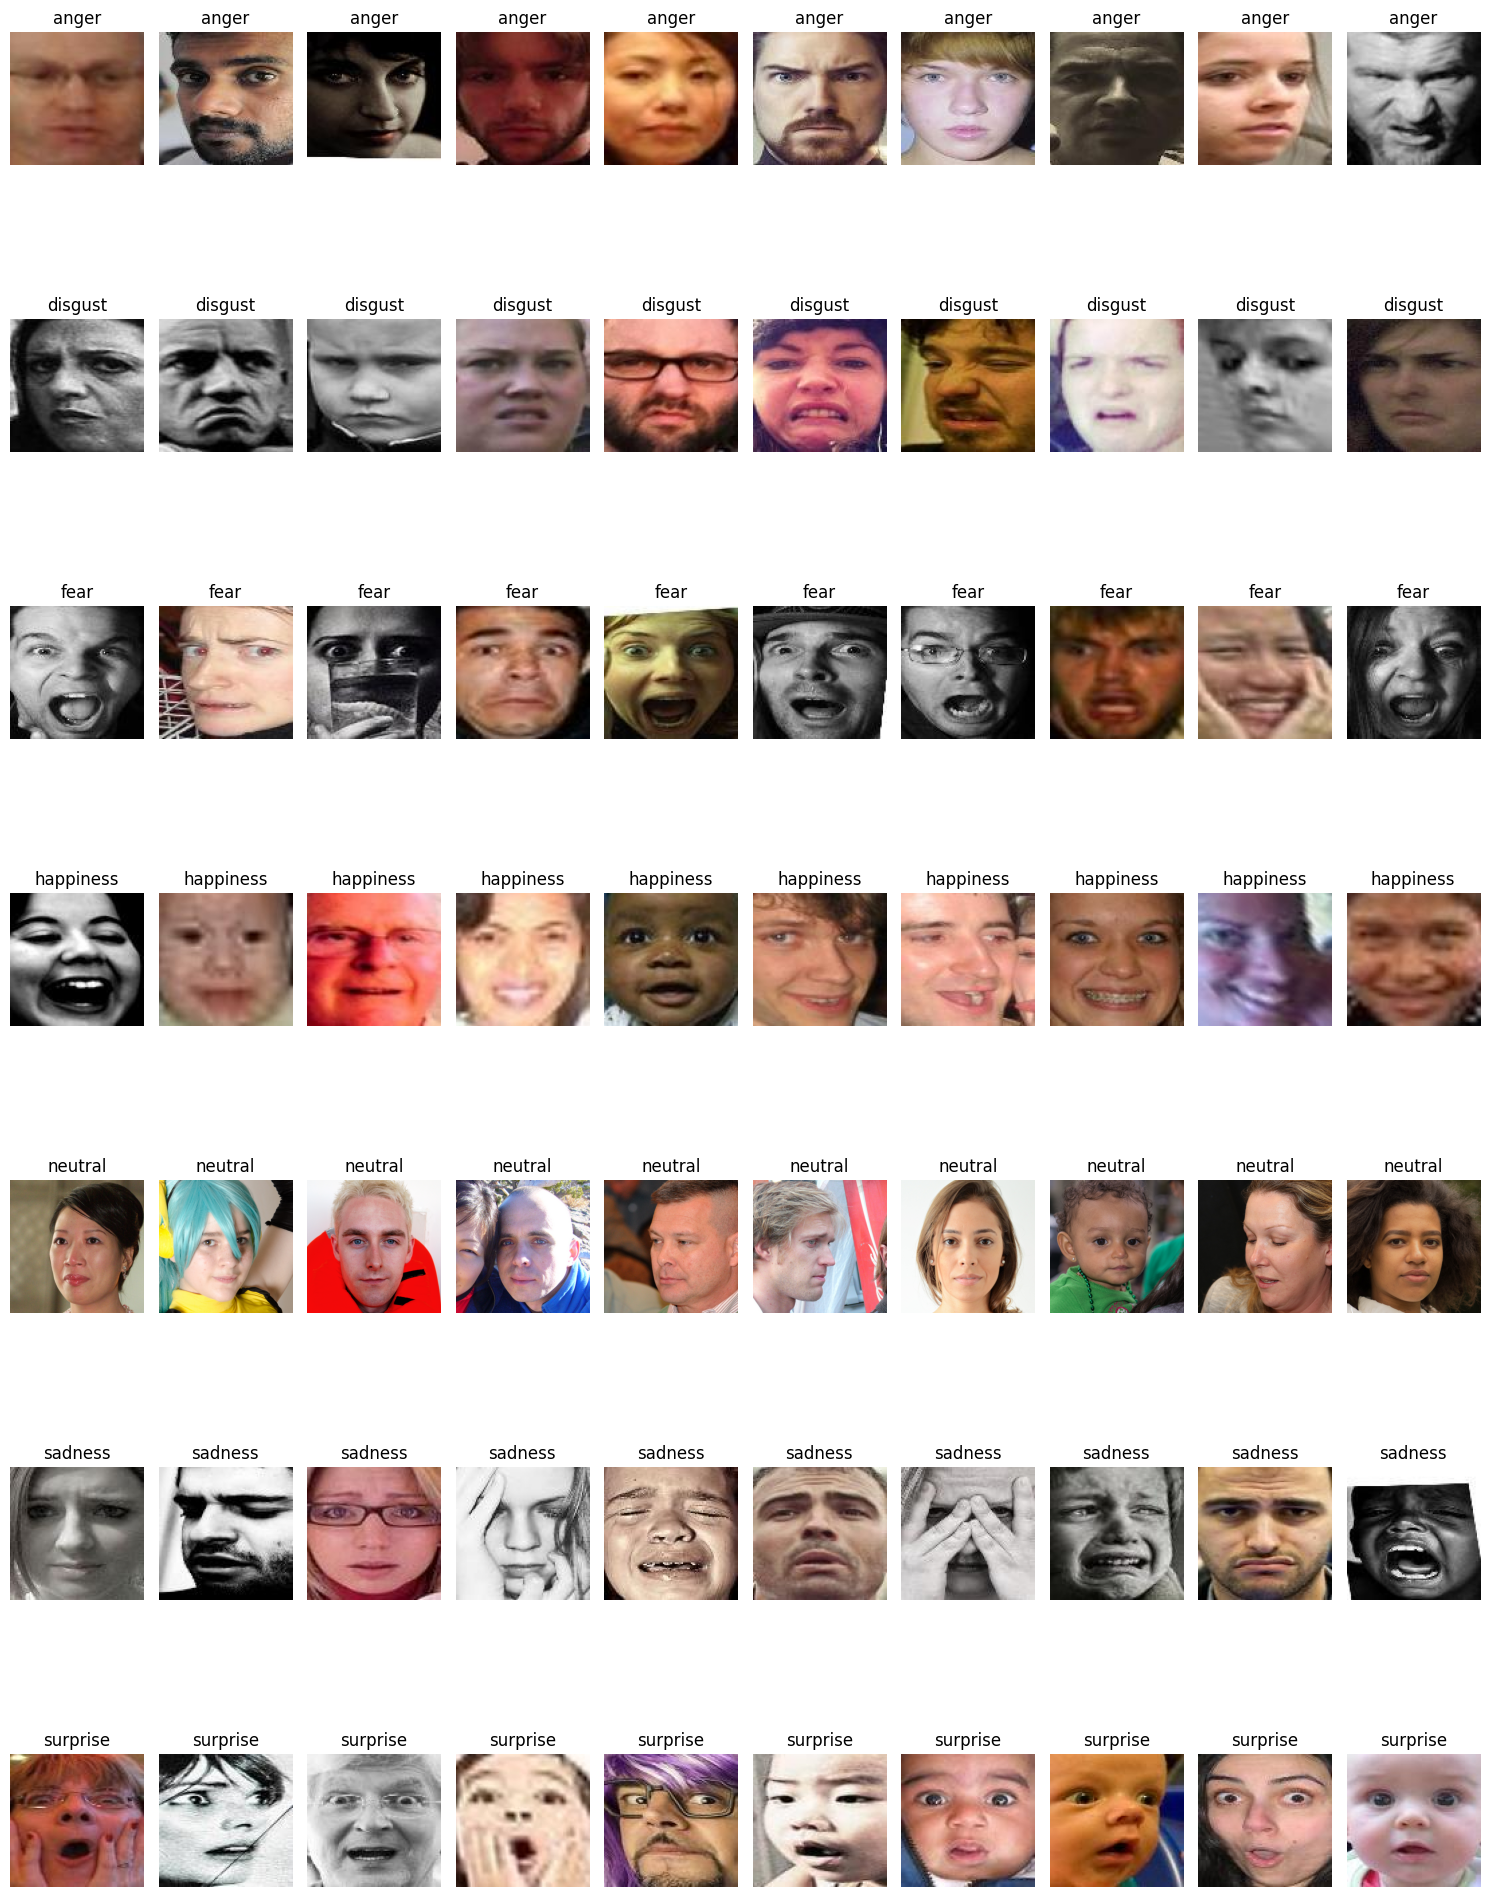

In [5]:
import matplotlib.pyplot as plt

num_examples = 10
num_classes = len(categories)
plt.figure(figsize=(15, num_classes*3))
for i in range(num_classes):
    count = 0
    for example in train_data:
        if example["label"] == i:
            plt.subplot(num_classes, num_examples, i*num_examples+count+1)
            plt.imshow(example["image"])
            plt.title(categories[i])
            plt.axis("off")
            count += 1
        if count == num_examples:
            break
plt.tight_layout()
plt.savefig("images/sample-expressions.png", dpi=200, bbox_inches="tight")
plt.show()

In [11]:
import tensorflow as tf
print(tf.config.list_physical_devices('GPU'))

[]


#### Training

In [55]:
# Load architecture
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Input, Conv2D, MaxPooling2D

# print('Load model')
# model = Sequential()
# model.add(Flatten(input_shape=(100, 100, 3)))
# model.add(Activation('relu'))
# model.add(Dense(num_classes))
# model.add(Activation('softmax'))
# model.summary()


print("Load model")
model = Sequential([
    Input(shape=(100, 100, 3)),
    Conv2D(32, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Conv2D(128, (3, 3), activation="relu", padding="same"),
    MaxPooling2D((2, 2)),
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(num_classes, activation="softmax")
])
model.summary()


Load model


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 100, 100, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 50, 50, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 50, 50, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 25, 25, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 25, 25, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 12, 12, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 18432)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │     2,359,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 7)              │           903 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,453,575 (9.36 MB)

 Trainable params: 2,453,575 (9.36 MB)

 Non-trainable params: 0 (0.00 B)

In [56]:
from tensorflow.keras.optimizers import Adam

# Learning rate is changed to 0.001
opt = Adam(learning_rate=1e-3, beta_1=0.9, beta_2=0.999, epsilon=1e-8, amsgrad=True, clipnorm=1.0)
model.compile(optimizer=opt, loss='categorical_crossentropy', metrics=['accuracy'])

In [57]:
from tensorflow.keras.callbacks import TerminateOnNaN, EarlyStopping, ReduceLROnPlateau, ModelCheckpoint

# Callbacks
model_checkpoint = ModelCheckpoint('model.keras', monitor='val_accuracy', verbose=1, save_best_only=True)
reduce_lr = ReduceLROnPlateau('val_accuracy', factor=0.1, patience=10, verbose=1)
early_stop = EarlyStopping('val_accuracy', patience=40, verbose=1)
terminate = TerminateOnNaN()
callbacks = [model_checkpoint, reduce_lr, early_stop, terminate]

In [58]:
import numpy as np
import tensorflow as tf

def generator_images(objs, batch_size):
    while True:
        for i in range(0, len(objs), batch_size):
            images, labels = [], []
            for j in range(i, min(i+batch_size, len(objs))):
                sample = objs[j]
                img = np.array(sample["image"]).astype(np.float32) / 255.0
                img = tf.image.resize(img, (100, 100))
                images.append(img)
                label = tf.keras.utils.to_categorical(sample["label"], num_classes)
                labels.append(label)
            yield np.array(images), np.array(labels)

In [59]:
import math

print("Training model")
epochs = 10
batch_size = 16

train_steps = math.ceil(len(train_data) / batch_size)
val_steps = math.ceil(len(val_data) / batch_size)

print("train:", len(train_data), train_steps)
print("val:", len(val_data), val_steps)

# Generators
train_generator = generator_images(train_data, batch_size)
val_generator = generator_images(val_data, batch_size)

h = model.fit(
    train_generator,
    epochs=epochs,
    verbose=1,
    callbacks=callbacks,
    steps_per_epoch=train_steps,
    validation_data=val_generator,
    validation_steps=val_steps
)

# Best model based on validation accuracy
best_idx = int(np.argmax(h.history["val_accuracy"]))
best_value = np.max(h.history["val_accuracy"])
print("Best validation model: epoch " + str(best_idx + 1) + " - val_accuracy " + str(best_value))

Training model
train: 13100 819
val: 3276 205
Epoch 1/10
818/819 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.5242 - loss: 1.2954
Epoch 1: val_accuracy improved from None to 0.70238, saving model to model.keras

Epoch 1: finished saving model to model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 47s 56ms/step - accuracy: 0.6079 - loss: 1.0869 - val_accuracy: 0.7024 - val_loss: 0.8152 - learning_rate: 0.0010
Epoch 2/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - accuracy: 0.6845 - loss: 0.8732
Epoch 2: val_accuracy improved from 0.70238 to 0.74664, saving model to model.keras

Epoch 2: finished saving model to model.keras
819/819 ━━━━━━━━━━━━━━━━━━━━ 46s 56ms/step - accuracy: 0.6996 - loss: 0.8262 - val_accuracy: 0.7466 - val_loss: 0.6973 - learning_rate: 0.0010
Epoch 3/10
819/819 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - accuracy: 0.7232 - loss: 0.7635
Epoch 3: val_accuracy improved from 0.74664 to 0.76496, saving model to model.keras

Epoch 3: finished saving model to model.keras
819/819 ━━━━━━━━━

#### Evaluate test results


In [60]:
import numpy as np
from tqdm import tqdm

# model.load_weights('model.keras', by_name=True)
y_true, y_pred = [], []
for i in tqdm(range(len(test_data))):
    sample = test_data[i]
     # Load image
    img = np.array(sample["image"]).astype(np.float32) / 255.0
    img = tf.image.resize(img, (100, 100))
    # Generate prediction
    img = np.expand_dims(img, 0)
    predictions = model.predict(img, verbose=0)
    pred_label = np.argmax(predictions)
    # Save prediction
    y_true.append(sample["label"])
    y_pred.append(pred_label)

100%|██████████| 4095/4095 [02:09<00:00, 31.60it/s]


/var/folders/zt/x3pzpdb167d716d2rzx2f9wh0000gn/T/ipykernel_38995/2420754885.py:10: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))


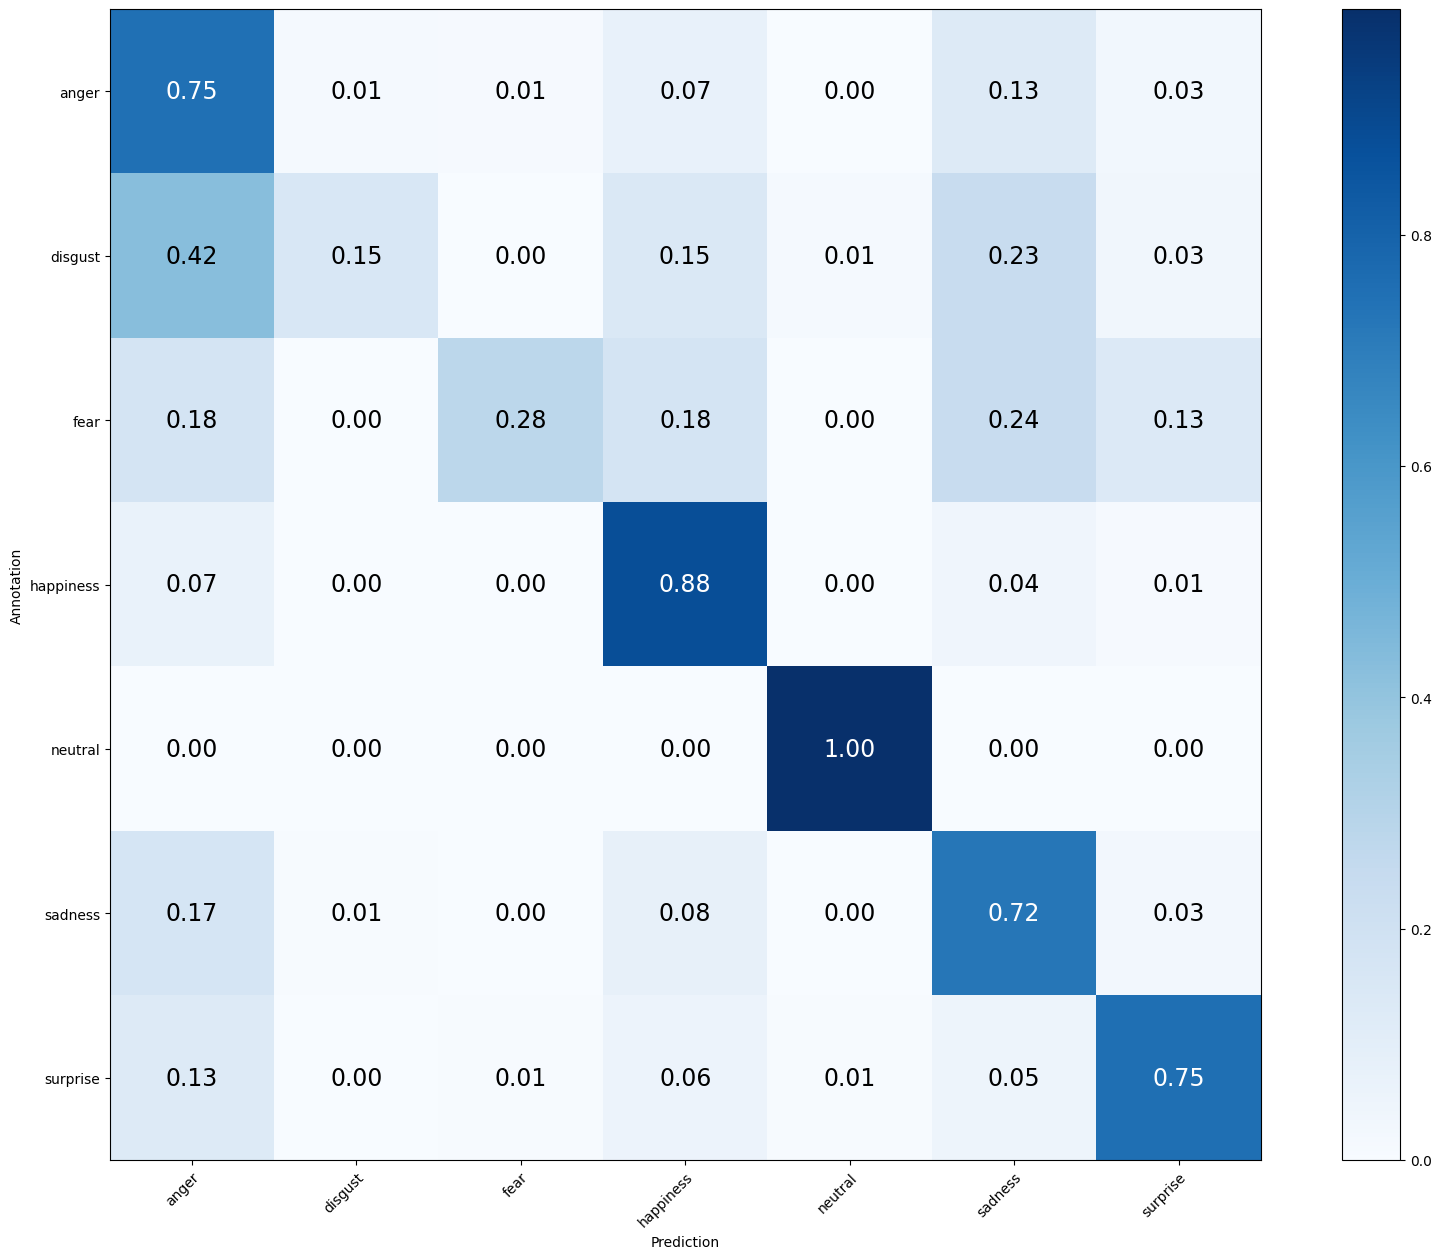

In [61]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

def draw_confusion_matrix(cm, categories):
    # Draw confusion matrix
    fig = plt.figure(figsize=[6.4*pow(len(categories), 0.5), 4.8*pow(len(categories), 0.5)])
    ax = fig.add_subplot(111)
    cm = cm.astype('float') / np.maximum(cm.sum(axis=1)[:, np.newaxis], np.finfo(np.float64).eps)
    im = ax.imshow(cm, interpolation='nearest', cmap=plt.cm.get_cmap('Blues'))
    ax.figure.colorbar(im, ax=ax)
    ax.set(xticks=np.arange(cm.shape[1]), yticks=np.arange(cm.shape[0]), xticklabels=list(categories.values()), yticklabels=list(categories.values()), ylabel='Annotation', xlabel='Prediction')
    # Rotate the tick labels and set their alignment
    plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")
    # Loop over data dimensions and create text annotations
    thresh = cm.max() / 2.0
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, format(cm[i, j], '.2f'), ha="center", va="center", color="white" if cm[i, j] > thresh else "black", fontsize=int(20-pow(len(categories), 0.5)))
    fig.tight_layout()
    plt.show(fig)

# Compute the confusion matrix
cm = confusion_matrix(y_true, y_pred, labels=list(categories.keys()))
draw_confusion_matrix(cm, categories)

In [62]:
import numpy as np

# Compute the accuracy
correct_samples_class = np.diag(cm).astype(float)
total_samples_class = np.sum(cm, axis=1).astype(float)
total_predicts_class = np.sum(cm, axis=0).astype(float)
print('Mean Accuracy: %.3f%%' % (np.sum(correct_samples_class) / np.sum(total_samples_class) * 100))
acc = correct_samples_class / np.maximum(total_samples_class, np.finfo(np.float64).eps)
print('Mean Recall: %.3f%%' % (acc.mean() * 100))
acc = correct_samples_class / np.maximum(total_predicts_class, np.finfo(np.float64).eps)
print('Mean Precision: %.3f%%' % (acc.mean() * 100))
for idx in range(len(categories)):
    # True/False Positives (TP/FP) refer to the number of predicted positives that were correct/incorrect.
    # True/False Negatives (TN/FN) refer to the number of predicted negatives that were correct/incorrect.
    tp = cm[idx, idx]
    fp = sum(cm[:, idx]) - tp
    fn = sum(cm[idx, :]) - tp
    tn = sum(np.delete(sum(cm) - cm[idx, :], idx))
    # True Positive Rate: proportion of real positive cases that were correctly predicted as positive.
    recall = tp / np.maximum(tp+fn, np.finfo(np.float64).eps)
    # Precision: proportion of predicted positive cases that were truly real positives.
    precision = tp / np.maximum(tp+fp, np.finfo(np.float64).eps)
    # True Negative Rate: proportion of real negative cases that were correctly predicted as negative.
    specificity = tn / np.maximum(tn+fp, np.finfo(np.float64).eps)
    # Dice coefficient refers to two times the intersection of two sets divided by the sum of their areas.
    # Dice = 2 |A∩B| / (|A|+|B|) = 2 TP / (2 TP + FP + FN)
    f1_score = 2 * ((precision * recall) / np.maximum(precision+recall, np.finfo(np.float64).eps))
    print('> %s: Recall: %.3f%% Precision: %.3f%% Specificity: %.3f%% Dice: %.3f%%' % (list(categories.values())[idx], recall*100, precision*100, specificity*100, f1_score*100))

Mean Accuracy: 81.416%
Mean Recall: 64.770%
Mean Precision: 74.359%
> anger: Recall: 75.000% Precision: 68.831% Specificity: 91.130% Dice: 71.783%
> disgust: Recall: 15.190% Precision: 61.538% Specificity: 99.619% Dice: 24.365%
> fear: Recall: 27.941% Precision: 61.290% Specificity: 99.702% Dice: 38.384%
> happiness: Recall: 88.205% Precision: 86.869% Specificity: 94.667% Dice: 87.532%
> neutral: Recall: 99.505% Precision: 99.604% Specificity: 99.870% Dice: 99.555%
> sadness: Recall: 72.320% Precision: 62.248% Specificity: 93.719% Dice: 66.907%
> surprise: Recall: 75.229% Precision: 80.130% Specificity: 98.381% Dice: 77.603%
